In [2]:
!pip install gym yfinance ta

  Using cached requests-2.32.5-py3-none-any.whl.metadata (4.9 kB)
   ---------------------------------------- 0.0/64.7 kB ? eta -:--:--
   ------ --------------------------------- 10.2/64.7 kB ? eta -:--:--
   ------ --------------------------------- 10.2/64.7 kB ? eta -:--:--
   ------------------ --------------------- 30.7/64.7 kB 220.2 kB/s eta 0:00:01
   ------------------------- -------------- 41.0/64.7 kB 196.9 kB/s eta 0:00:01
   ---------------------------------------- 64.7/64.7 kB 250.0 kB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.30.0
    Uninstalling requests-2.30.0:
      Successfully uninstalled requests-2.30.0


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
conda-repo-cli 1.0.75 requires requests_mock, which is not installed.
chromadb 0.4.12 requires pydantic<2.0,>=1.9, but you have pydantic 2.12.0 which is incompatible.
conda-repo-cli 1.0.75 requires clyent==1.2.1, but you have clyent 1.2.2 which is incompatible.
conda-repo-cli 1.0.75 requires requests==2.31.0, but you have requests 2.32.5 which is incompatible.
google-genai 1.25.0 requires anyio<5.0.0,>=4.8.0, but you have anyio 3.7.1 which is incompatible.
langchain 0.0.300 requires langsmith<0.1.0,>=0.0.38, but you have langsmith 0.4.34 which is incompatible.
langchain-community 0.3.27 requires langchain<1.0.0,>=0.3.26, but you have langchain 0.0.300 which is incompatible.
streamlit 1.30.0 requires packaging<24,>=16.8, but you have packaging 24.2 which is incompatible.
streamlit 1.30.0 requires protobuf<5,>=3.20,

# Libraries

In [54]:
!pip install gymnasium

In [56]:
import gym
import yfinance as yf
import ta  
from tqdm import tqdm
import numpy as np
import pandas as pd
from itertools import accumulate
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
sns.set_style("darkgrid")

### Loading Data

In [10]:
tickers = "TSLA"
dt = yf.download(tickers = tickers ,
                  period = "2y",        
                  interval = "1h",      
                  ignore_tz = True,      
                  prepost = False)       
print("shape of dataset: ",dt.shape)
dt.head()

C:\Users\girid\AppData\Local\Temp\ipykernel_152568\1226654400.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  dt = yf.download(tickers = tickers ,
[*********************100%***********************]  1 of 1 completed

shape of dataset:  (3487, 5)


Price,Close,High,Low,Open,Volume
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA
Datetime,,,,,
2023-10-30 09:30:00,201.440002,211.350006,198.210007,209.279999,31070587
2023-10-30 10:30:00,198.339905,204.759995,193.369995,201.449997,30474491
2023-10-30 11:30:00,198.205597,203.050003,194.330002,198.316299,15818940
2023-10-30 12:30:00,196.585007,201.429993,191.250000,198.199997,17441602
2023-10-30 13:30:00,195.780106,198.470001,195.759995,196.618103,13786774


In [12]:
split_line = int(np.round(len(dt)* 0.1))

C:\Users\girid\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\girid\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


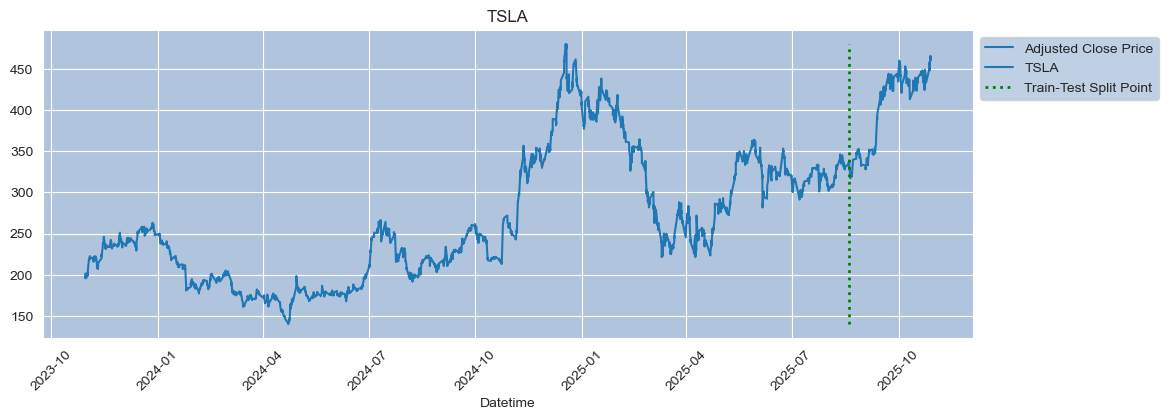

In [14]:
adj_close_min = dt['Close'].min()
adj_close_max = dt['Close'].max()
sns.set_style(rc = {'axes.facecolor': 'lightsteelblue'})
plt.figure(figsize=(12,4))
sns.lineplot(data=dt["Close"],label = "Adjusted Close Price")
plt.xticks(rotation=45)
plt.title(tickers)
plt.vlines(x=dt.index[-split_line], ymin=adj_close_min, ymax=adj_close_max, colors='green', ls=':', lw=2, label='Train-Test Split Point')

plt.legend(bbox_to_anchor=(1.0, 1), loc='upper left')
plt.show()

# Data Preparation 

### 1.Trend Indicator (Exponential Moving Average)

In [16]:
print(type(dt[['Close']]))

<class 'pandas.core.frame.DataFrame'>


In [18]:
cl = dt[['Close']].squeeze() # convertion  of dataframe to series

In [20]:
dt['EMA7'] = ta.trend.EMAIndicator(close= cl, window= 7, fillna= False).ema_indicator()
dt['EMA14'] = ta.trend.EMAIndicator(close= cl, window= 14, fillna= False).ema_indicator()
dt['EMA50'] = ta.trend.EMAIndicator(close=cl, window= 50, fillna= False).ema_indicator()
dt['EMA200'] = ta.trend.EMAIndicator(close= cl, window= 50, fillna= False).ema_indicator()

C:\Users\girid\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\girid\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\girid\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\girid\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating

Text(0.5, 1.0, 'TSLA')

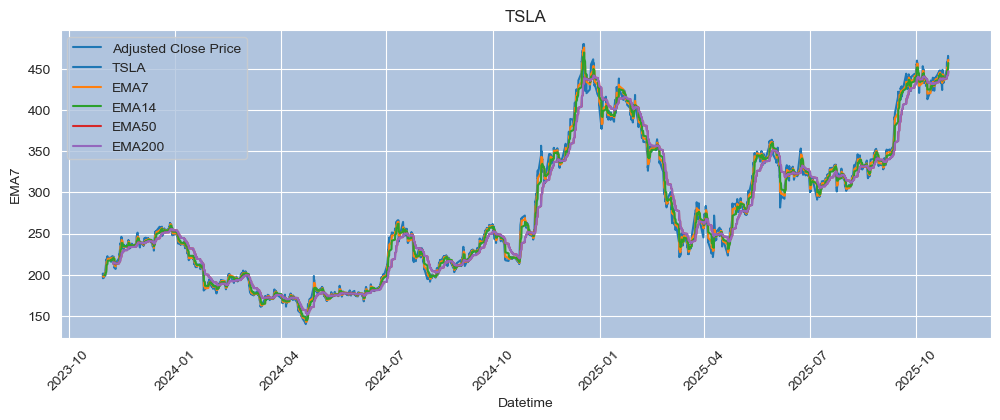

In [22]:
sns.set_style(rc = {'axes.facecolor': 'lightsteelblue'})
plt.figure(figsize=(12,4))
sns.lineplot(data=dt["Close"],label = "Adjusted Close Price")
sns.lineplot(data=dt["EMA7"],label = "EMA7")
sns.lineplot(data=dt["EMA14"],label = "EMA14")
sns.lineplot(data=dt["EMA50"],label = "EMA50")
sns.lineplot(data=dt["EMA200"],label = "EMA200")


plt.xticks(rotation=45)
plt.title(tickers)

### 2.Momentum Indicator (Relative Strength Index & Moving Average Convergence Divergence)

In [24]:
dt['MACD_line'] =ta.trend.MACD(close= cl, window_slow= 26, window_fast= 12, window_sign = 9, fillna = False).macd()
dt['MACD_signal'] =ta.trend.MACD(close= cl, window_slow= 26, window_fast= 12, window_sign = 9, fillna = False).macd_signal()
dt['MACD_diff'] =ta.trend.MACD(close= cl, window_slow= 26, window_fast= 12, window_sign = 9, fillna = False).macd_diff()

C:\Users\girid\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\girid\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\girid\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\girid\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating

Text(0.5, 1.0, 'TSLA')

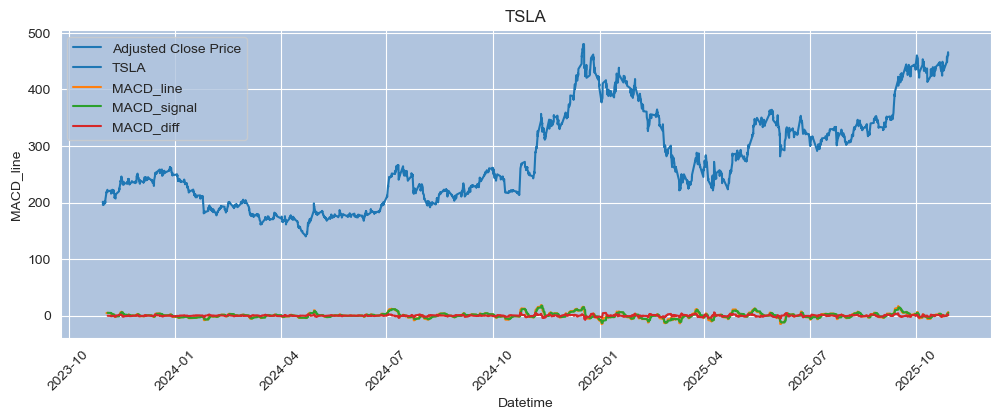

In [26]:
sns.set_style(rc = {'axes.facecolor': 'lightsteelblue'})
plt.figure(figsize=(12,4))
sns.lineplot(data=dt["Close"],label = "Adjusted Close Price")
sns.lineplot(data=dt["MACD_line"],label = "MACD_line")
sns.lineplot(data=dt["MACD_signal"],label = "MACD_signal")
sns.lineplot(data=dt["MACD_diff"],label = "MACD_diff")

plt.xticks(rotation=45)
plt.title(tickers)

In [28]:
dt['RSI']=ta.momentum.RSIIndicator(close= cl, window= 14, fillna= False).rsi()

C:\Users\girid\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\girid\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\girid\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\girid\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating

Text(0.5, 1.0, 'TSLA')

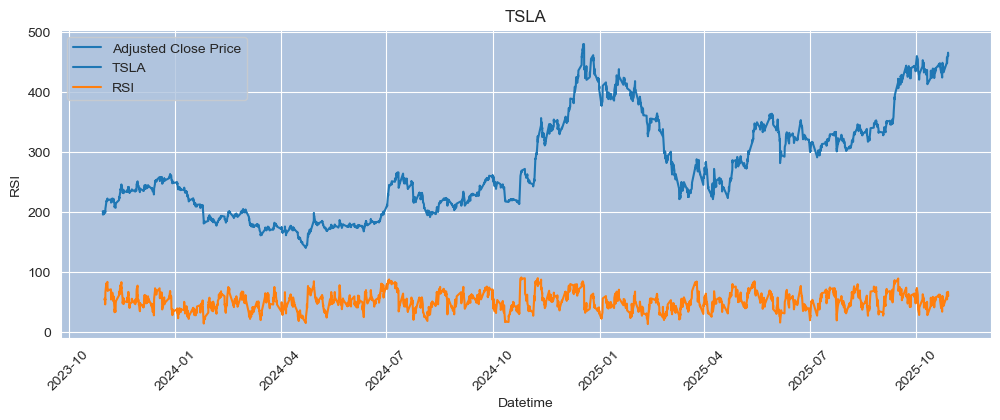

In [30]:
sns.set_style(rc = {'axes.facecolor': 'lightsteelblue'})
plt.figure(figsize=(12,4))
sns.lineplot(data=dt["Close"],label = "Adjusted Close Price")
sns.lineplot(data=dt["RSI"],label = "RSI")
plt.xticks(rotation=45)
plt.title(tickers)

### 3.Volume Indicator (On Balance Volume)

In [33]:
vl = dt[['Volume']].squeeze()
dt['OBV']= ta.volume.OnBalanceVolumeIndicator(close=cl, volume= vl, fillna = False).on_balance_volume()
dt.head()

Price,Close,High,Low,Open,Volume,EMA7,EMA14,EMA50,EMA200,MACD_line,MACD_signal,MACD_diff,RSI,OBV
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA,,,,,,,,,
Datetime,,,,,,,,,,,,,,
2023-10-30 09:30:00,201.440002,211.350006,198.210007,209.279999,31070587,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,31070587
2023-10-30 10:30:00,198.339905,204.759995,193.369995,201.449997,30474491,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,596096
2023-10-30 11:30:00,198.205597,203.050003,194.330002,198.316299,15818940,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-15222844
2023-10-30 12:30:00,196.585007,201.429993,191.250000,198.199997,17441602,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-32664446
2023-10-30 13:30:00,195.780106,198.470001,195.759995,196.618103,13786774,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-46451220


C:\Users\girid\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\girid\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\girid\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\girid\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating

Text(0.5, 1.0, 'TSLA')

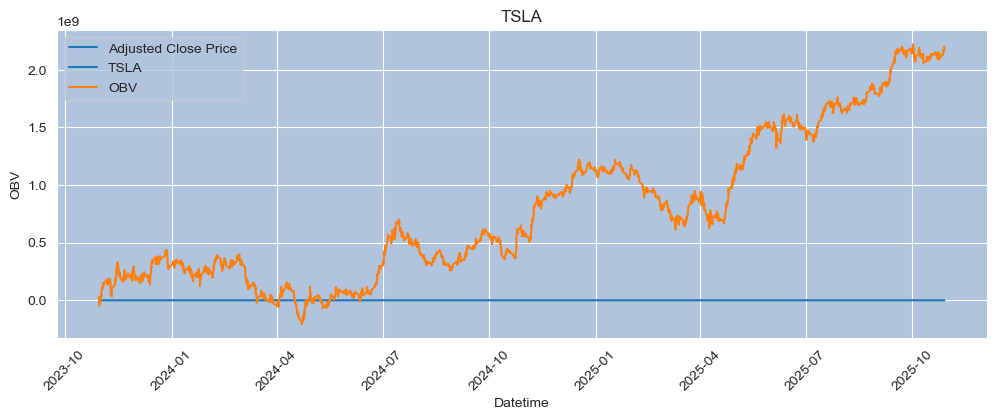

In [35]:
sns.set_style(rc = {'axes.facecolor': 'lightsteelblue'})
plt.figure(figsize=(12,4))
sns.lineplot(data=dt["Close"],label = "Adjusted Close Price")
sns.lineplot(data=dt["OBV"],label = "OBV")
plt.xticks(rotation=45)
plt.title(tickers)

### 4.Volatile Indicator (Bollinger Bands)

In [38]:
dt['BBH']=ta.volatility.BollingerBands(cl, window = 20, window_dev = 2, fillna = False).bollinger_hband_indicator()
dt['BBL']=ta.volatility.BollingerBands(cl, window = 20, window_dev = 2, fillna = False).bollinger_lband_indicator()
dt.head()

Price,Close,High,Low,Open,Volume,EMA7,EMA14,EMA50,EMA200,MACD_line,MACD_signal,MACD_diff,RSI,OBV,BBH,BBL
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA,,,,,,,,,,,
Datetime,,,,,,,,,,,,,,,,
2023-10-30 09:30:00,201.440002,211.350006,198.210007,209.279999,31070587,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,31070587,0.0,0.0
2023-10-30 10:30:00,198.339905,204.759995,193.369995,201.449997,30474491,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,596096,0.0,0.0
2023-10-30 11:30:00,198.205597,203.050003,194.330002,198.316299,15818940,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-15222844,0.0,0.0
2023-10-30 12:30:00,196.585007,201.429993,191.250000,198.199997,17441602,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-32664446,0.0,0.0
2023-10-30 13:30:00,195.780106,198.470001,195.759995,196.618103,13786774,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-46451220,0.0,0.0


C:\Users\girid\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\girid\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\girid\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\girid\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating

Text(0.5, 1.0, 'TSLA')

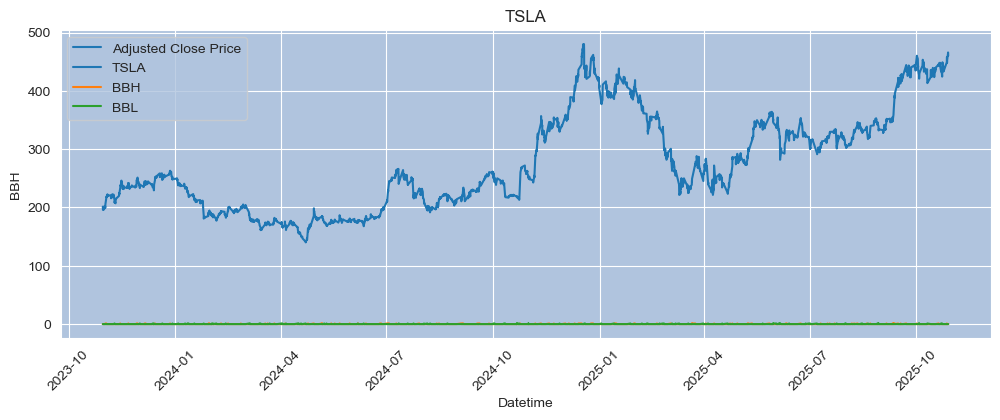

In [40]:
sns.set_style(rc = {'axes.facecolor': 'lightsteelblue'})
plt.figure(figsize=(12,4))
sns.lineplot(data=dt["Close"],label = "Adjusted Close Price")
sns.lineplot(data=dt["BBH"],label = "BBH")
sns.lineplot(data=dt["BBL"],label = "BBL")
plt.xticks(rotation=45)
plt.title(tickers)

In [42]:
dt.columns

MultiIndex([(      'Close', 'TSLA'),
            (       'High', 'TSLA'),
            (        'Low', 'TSLA'),
            (       'Open', 'TSLA'),
            (     'Volume', 'TSLA'),
            (       'EMA7',     ''),
            (      'EMA14',     ''),
            (      'EMA50',     ''),
            (     'EMA200',     ''),
            (  'MACD_line',     ''),
            ('MACD_signal',     ''),
            (  'MACD_diff',     ''),
            (        'RSI',     ''),
            (        'OBV',     ''),
            (        'BBH',     ''),
            (        'BBL',     '')],
           names=['Price', 'Ticker'])

In [44]:
train_data = dt.iloc[:-split_line,:]
test_data = dt.iloc[-split_line:,:]
input_shape= train_data.shape[1]
print(input_shape)
print('Training data:',train_data.shape)
print('Testing data',test_data.shape)

16
Training data: (3138, 16)
Testing data (349, 16)


# Environment

### Setting up the action space and observation space

In [47]:
import gym
import numpy as np

class StockTradingEnv(gym.Env):
    def __init__(self, data, initial_cash=10000, commission=0.000):
        self.action_space = gym.spaces.MultiDiscrete([3, 10])  # [action, number of shares]
        self.observation_space = gym.spaces.Box(low=-np.inf, high=np.inf, shape=(12,), dtype=np.float32)
        self.data = data
        self.initial_cash = initial_cash
        self.commission = commission
        self.end_step = len(self.data) - 1

        self.reset()

    def reset(self):
        self.current_step = 0
        self.profits = 0
        self.shares_held = 0
        self.cash = self.initial_cash
        self.buy_price = 0
        self.sell_price = 0
        self.done = False
        return self._get_obs()

    def step(self, action):
        action_type, amount = action

        if action_type == 0: # Buy
            cost = (self.data['Close'].iloc[self.current_step] * amount).item()
            
            if self.cash >= cost:
                self.cash -= cost
                self.shares_held += amount
                self.buy_price = self.data['Close'].iloc[self.current_step]
        
        elif action_type == 1: # Sell
            shares_sold = min(self.shares_held, amount)
            revenue = (self.data['Close'].iloc[self.current_step] * shares_sold).item()
            
            self.cash += revenue
            self.profits += (self.data['Close'].iloc[self.current_step] - self.buy_price) * shares_sold
            self.shares_held -= shares_sold
            self.sell_price = self.data['Close'].iloc[self.current_step]

        self.current_step += 1
        
        portfolio_value = self.cash + (self.shares_held * self.data['Close'].iloc[self.current_step])
        reward = portfolio_value - (self.cash + (self.shares_held * self.data['Close'].iloc[self.current_step - 1]))
        
        done = (self.current_step == self.end_step)
        return self._get_obs(), reward, done, {}

    def _get_obs(self):
        obs = np.array([
            float(self.data['Close'].iloc[self.current_step]),
            float(self.data['EMA7'].iloc[self.current_step]),
            float(self.data['EMA14'].iloc[self.current_step]),
            float(self.data['EMA50'].iloc[self.current_step]),
            float(self.data['EMA200'].iloc[self.current_step]),
            float(self.data['MACD_line'].iloc[self.current_step]),
            float(self.data['MACD_signal'].iloc[self.current_step]),
            float(self.data['MACD_diff'].iloc[self.current_step]),
            float(self.data['RSI'].iloc[self.current_step]),
            float(self.data['OBV'].iloc[self.current_step]),
            float(self.data['BBH'].iloc[self.current_step]),
            float(self.data['BBL'].iloc[self.current_step]),
        ])
        return obs

# Defining the Agent


In [58]:
import random
import numpy as np
from collections import deque
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD, Adam

class DQNAgent:
    def __init__(self, state_size, action_space,memory_size=3000):
        self.state_size = state_size
        self.action_space = action_space
        self.action_size = action_space.nvec.prod()
        self.memory = deque(maxlen=memory_size)
        self.gamma = 0.95
        self.epsilon = 1.0
        self.epsilon_min = 0.01
        self.epsilon_decay = 0.995
        self.learning_rate = 0.01
        self.model = self._build_model()

    def _build_model(self):
        model = Sequential()
        model.add(Dense(64, input_dim=self.state_size))
        model.add(Dense(128, activation='relu'))
        model.add(Dense(256, activation='relu'))
        model.add(Dense(128, activation='relu'))
        model.add(Dense(self.action_size, activation='relu'))
        model.compile(loss='mse', optimizer=Adam(learning_rate=self.learning_rate))
        return model

    def remember(self, state, action, reward, next_state, done):
        self.memory.append((state, action, reward, next_state, done))

    def act(self, state):
        if np.random.rand() <= self.epsilon:
            return (random.randrange(self.action_space.nvec[0]), random.randrange(self.action_space.nvec[1]))
        act_values = self.model.predict(state)
        return np.unravel_index(np.argmax(act_values[0]), self.action_space.nvec)

    def replay(self, batch_size):
        minibatch = random.sample(self.memory, batch_size)
        for state, action, reward, next_state, done in minibatch:
            target = reward
            if not done:
                target = reward + self.gamma * np.amax(self.model.predict(next_state)[0])
            target_f = self.model.predict(state)
            action_idx = np.ravel_multi_index(action, self.action_space.nvec)
            target_f[0][action_idx] = target
            self.model.fit(state, target_f, epochs=1, verbose=0)
        if self.epsilon > self.epsilon_min:
            self.epsilon *= self.epsilon_decay


# Training the Agent

In [60]:
data = train_data
env = StockTradingEnv(data)
state_size = env.observation_space.shape[0]
action_size = env.action_space.nvec.prod()
agent = DQNAgent(state_size, env.action_space)
episodes = 50
batch_size = 32

for e in tqdm(range(episodes)):
    state = env.reset()
    state = np.reshape(state, [1, state_size])
    total_reward = 0

    while True:
        action = agent.act(state)
        next_state, reward, done, _ = env.step(action)
        total_reward += reward
        next_state = np.reshape(next_state, [1, state_size])

        agent.remember(state, action, reward, next_state, done)
        state = next_state

        if done:
            print(f'Episode: {e + 1}/{episodes}, Total Reward: {total_reward}, Epsilon: {agent.epsilon:.2}')
            break

    if len(agent.memory) > batch_size:
        agent.replay(batch_size)


C:\Users\girid\AppData\Local\Temp\ipykernel_152568\2610309972.py:55: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  float(self.data['Close'].iloc[self.current_step]),


  0%|                                                                                           | 0/50 [00:00<?, ?it/s]

Episode: 1/50, Total Reward: Ticker
TSLA    8265.926788
dtype: float64, Epsilon: 1.0
1/1 [==============================] - 0s 61ms/step


C:\Users\girid\AppData\Local\Temp\ipykernel_152568\1712559948.py:48: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  target_f[0][action_idx] = target



1/1 [==============================] - 0s 40ms/step


...

 96%|██████████████████████████████████████████████████████████████████████████████▋   | 48/50 [52:27<02:58, 89.08s/it]

1/1 [==============================] - 0s 45ms/step
Episode: 49/50, Total Reward: Ticker
TSLA    5466.896622
dtype: float64, Epsilon: 0.79
1/1 [==============================] - 0s 21ms/step


 98%|████████████████████████████████████████████████████████████████████████████████▎ | 49/50 [53:58<01:29, 89.62s/it]

1/1 [==============================] - 0s 22ms/step
Episode: 50/50, Total Reward: Ticker
TSLA    1346.635071
dtype: float64, Epsilon: 0.78
1/1 [==============================] - 0s 23ms/step


100%|██████████████████████████████████████████████████████████████████████████████████| 50/50 [55:39<00:00, 66.78s/it]


# Testing the Agent

1/1 [==============================] - 0s 37ms/step


C:\Users\girid\AppData\Local\Temp\ipykernel_152568\2610309972.py:55: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  float(self.data['Close'].iloc[self.current_step]),


1/1 [==============================] - 0s 20ms/step
Test: Total Reward: Ticker
TSLA    676.482391
dtype: float64


C:\Users\girid\anaconda3\Lib\site-packages\matplotlib\cbook.py:1699: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return math.isfinite(val)


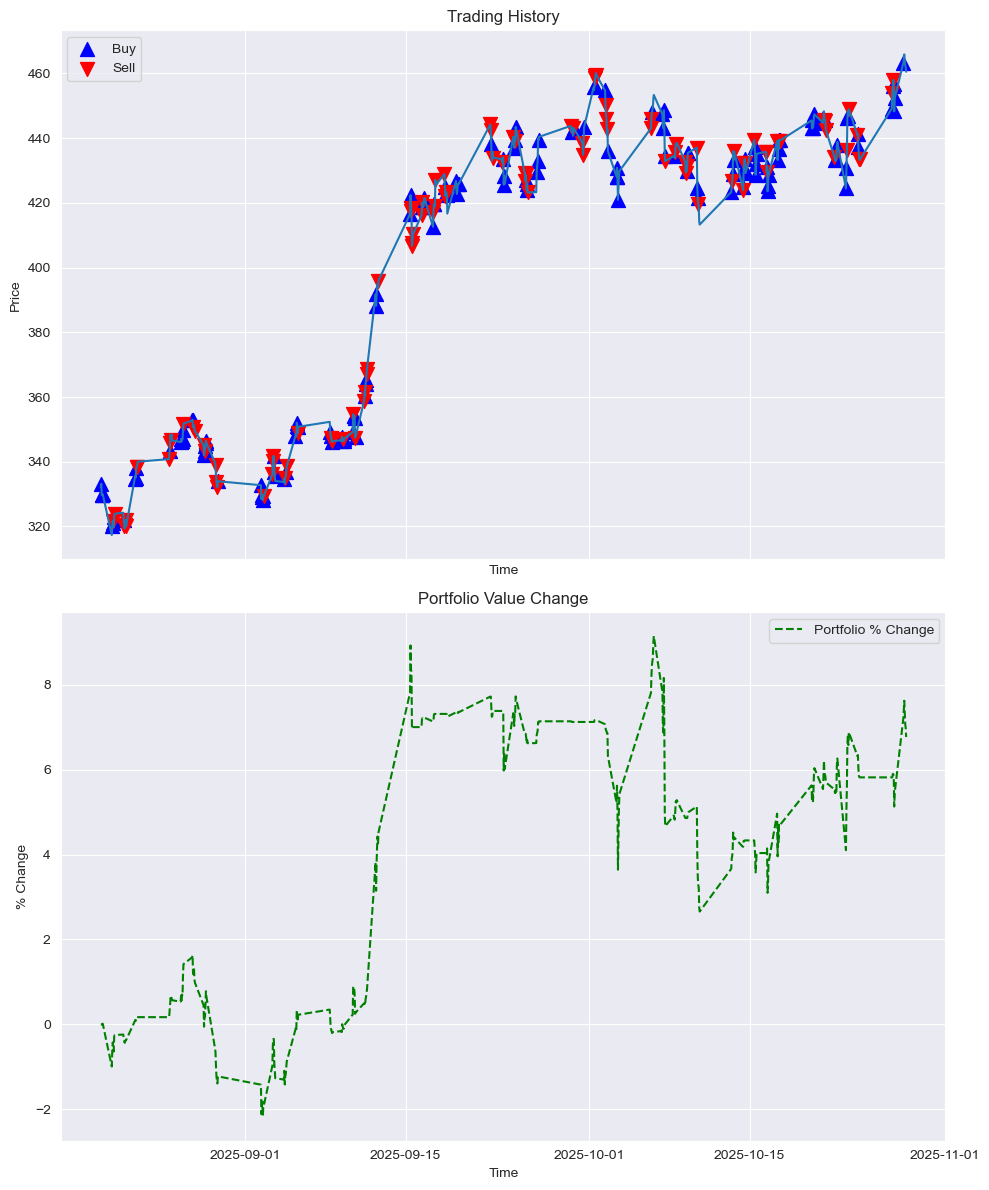

In [62]:
import matplotlib.pyplot as plt
import numpy as np
test_data = test_data.iloc[:,:] 
verbose = 0
test_env = StockTradingEnv(test_data, initial_cash=10000)
state = test_env.reset()
state = np.reshape(state, [1, state_size])
total_reward = 0
buy_prices = []
buy_times = []
sell_prices = []
sell_times = []
portfolio_values = [test_env.cash]

while True:
    action = agent.act(state)
    next_state, reward, done, _ = test_env.step(action)
    portfolio_value = (test_env.cash + (test_env.shares_held * test_env.data['Close'].iloc[test_env.current_step])).item()
    portfolio_values.append(portfolio_value)
    action_type, shares = action
    if(verbose == 1):
        if action_type == 0:
            print(f"Buy {shares} shares at price {test_env.data['Close'].iloc[test_env.current_step]}")
        elif action_type == 1:
            print(f"Sell {shares} shares at price {test_env.data['Close'].iloc[test_env.current_step]}")

        print(f"Available cash: {test_env.cash}",f",Shares held: {test_env.shares_held}",f",Reward: {reward}")
        print("------------------------------------------------")

    total_reward += reward
    next_state = np.reshape(next_state, [1, state_size])
    state = next_state
    if action[0] == 0:
        buy_prices.append(test_data['Close'].iloc[test_env.current_step])
        buy_times.append(test_data.index[test_env.current_step])
    elif action[0] == 1:
        sell_prices.append(test_data['Close'].iloc[test_env.current_step])
        sell_times.append(test_data.index[test_env.current_step])

    if done:
        print(f'Test: Total Reward: {total_reward}')
        break
portfolio_percentage_changes = [((value - portfolio_values[0]) / portfolio_values[0]) * 100 for value in portfolio_values]
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 12), sharex=True)
ax1.plot(test_data.index, test_data['Close'])
ax1.scatter(buy_times, buy_prices, color='b', marker='^', label='Buy', s=100)
ax1.scatter(sell_times, sell_prices, color='r', marker='v', label='Sell', s=100)
ax1.set_title('Trading History')
ax1.set_xlabel('Time')
ax1.set_ylabel('Price')
ax1.legend()

ax2.plot(test_data.index, portfolio_percentage_changes[:len(test_data.index)], color='g', linestyle='--', label='Portfolio % Change')
ax2.set_title('Portfolio Value Change')
ax2.set_xlabel('Time')
ax2.set_ylabel('% Change')
ax2.legend()


plt.tight_layout()
plt.show()

### Monte carlo Evaluation

In [66]:
test_data = test_data
test_env = StockTradingEnv(test_data,initial_cash =100000)
monte_carlo_runs = 200
rewards = []

for run in tqdm(range(monte_carlo_runs)):
    state = test_env.reset()
    state = np.reshape(state, [1, state_size])
    total_reward = 0

    while True:
        action = agent.act(state)
        next_state, reward, done, _ = test_env.step(action)
        total_reward += reward
        next_state = np.reshape(next_state, [1, state_size])
        state = next_state

        if done:
            # print(f'Test Run: {run + 1}/{monte_carlo_runs}, Total Reward: {total_reward}')
            rewards.append(total_reward)
            break
average_reward = np.mean(rewards)
print(f'Average Reward after {monte_carlo_runs} runs: {average_reward}')


C:\Users\girid\AppData\Local\Temp\ipykernel_152568\2610309972.py:55: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  float(self.data['Close'].iloc[self.current_step]),
  0%|                                                                                          | 0/200 [00:00<?, ?it/s]

1/1 [==============================] - 0s 39ms/step


  0%|▍                                                                               | 1/200 [00:18<1:01:56, 18.67s/it]

1/1 [==============================] - 0s 60ms/step


  1%|▊                                                                               | 2/200 [00:37<1:01:02, 18.50s/it]

...

1/1 [==============================] - 0s 62ms/step


100%|█████████████████████████████████████████████████████████████████████████████▌| 199/200 [1:01:43<00:19, 19.31s/it]

1/1 [==============================] - 0s 55ms/step


100%|██████████████████████████████████████████████████████████████████████████████| 200/200 [1:02:00<00:00, 18.60s/it]

Average Reward after 200 runs: 4710.883051605225
